# EDA: mercado europeo de motos de segunda mano

**Ejercicio práctico:** carga, exploración, limpieza y visualización básica de un dataset.

El dataset recoge anuncios de motos publicados en un gran marketplace europeo de vehículos. El objetivo es **entender el dataset, detectar sus problemas de calidad, limpiarlo de forma justificada y describir sus características principales** con visualizaciones sencillas. No se hacen análisis estadísticos avanzados ni modelos.

**Índice**
1. Carga del dataset
2. Exploración
3. Limpieza y normalización
4. Visualizaciones básicas
5. Conclusiones exploratorias

## 0. Librerías y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Rutas (el notebook está en notebooks/, los datos en data/)
RUTA_DATOS = Path("../data/dataset.csv")
RUTA_LIMPIO = Path("../data/dataset_clean.csv")
RUTA_IMAGENES = Path("../images")
RUTA_IMAGENES.mkdir(exist_ok=True)

# Fecha en la que se recogieron los anuncios (según la fuente). Se usa para calcular la antigüedad.
FECHA_CAPTURA = pd.Timestamp("2021-07-16")

# Estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 110,
                     "axes.titleweight": "bold", "axes.titlesize": 13})
COLOR = "#2E5A87"
COLOR_2 = "#C8553D"

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Carga del dataset

**Fuente:** *Europe Motorbikes* publicado por ZenRows (zenrows.com/datasets/europe-motorbikes), con algo más de 35.000 anuncios extraídos el 16/07/2021 de un gran marketplace europeo. Por la estructura de los enlaces (`/offers/...`), los anuncios proceden de AutoScout24.

In [2]:
df_raw = pd.read_csv(RUTA_DATOS)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
df_raw.head()

Filas: 34,917 | Columnas: 10


,price,mileage,power,make_model,date,fuel,gear,offer_type,version,link
0,23990,150,218.00,Honda,03/2020,Gasoline,Manual,Demonstration,CBR1000RR-R Fireblade SP,/offers/honda-others-cbr1000rr-r-fireblade-sp-...
1,7500,2871,90.00,BMW F 800 GT,09/2018,Gasoline,Manual,Used,NaN,/offers/bmw-f-800-gt-gasoline-white-f65273c6-6...
2,800,1700,3.00,Nova Motors Retro Star,10/2019,Gasoline,NaN,Used,NaN,/offers/nova-motors-retro-star-gasoline-red-f8...
3,14990,24345,NaN,Aprilia RSV4,03/2016,Gasoline,NaN,Used,RF,/offers/aprilia-rsv4-rf-gasoline-silver-1b51fe...
4,6200,25000,128.00,Kawasaki Ninja ZX-6R,08/2009,Gasoline,NaN,Used,NaN,/offers/kawasaki-ninja-zx-6r-gasoline-blue-2f8...


In [3]:
# Tipos de datos y valores no nulos por columna
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 34917 entries, 0 to 34916
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       34917 non-null  int64  
 1   mileage     34917 non-null  int64  
 2   power       28598 non-null  float64
 3   make_model  34917 non-null  str    
 4   date        34917 non-null  str    
 5   fuel        31727 non-null  str    
 6   gear        12847 non-null  str    
 7   offer_type  34917 non-null  str    
 8   version     17413 non-null  str    
 9   link        34917 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 2.7 MB


**Descripción de las columnas**

| Columna | Tipo detectado | Qué representa | Tipo real |
|---|---|---|---|
| `price` | entero | Precio del anuncio (€) | Numérica |
| `mileage` | entero | Kilómetros recorridos | Numérica |
| `power` | decimal | Potencia (CV) | Numérica |
| `make_model` | texto | Marca y modelo juntos | Categórica (hay que separar) |
| `date` | **texto** | Mes/año de primera matriculación (`MM/YYYY`) | **Fecha** (hay que convertir) |
| `fuel` | texto | Combustible | Categórica |
| `gear` | texto | Tipo de cambio | Categórica |
| `offer_type` | texto | Usada, nueva, demostración, etc. | Categórica |
| `version` | texto | Versión escrita libremente por el vendedor | Texto libre |
| `link` | texto | Ruta del anuncio | Identificador |

Primera observación: `date` se ha leído como texto y `make_model` mezcla dos variables en una.

## 2. Exploración del dataset

### 2.1 Contexto, fiabilidad y granularidad

- **Dominio:** mercado de motos de segunda mano (y algunas nuevas) en Europa. Las variables son intuitivas: precio, kilómetros, potencia, antigüedad, marca, combustible.
- **Fiabilidad:** los datos son **anuncios introducidos por los vendedores** (particulares y concesionarios). Es de esperar que haya errores de tecleo, valores de relleno y campos opcionales vacíos. El precio es el **precio pedido**, no el de venta final.
- **Granularidad:** datos **individuales**, una fila = un anuncio. No hay agregaciones.
- **Identificador:** `link` identifica cada anuncio de forma única, así que sirve para detectar duplicados.
- **Cobertura temporal:** una única foto del mercado (julio de 2021), no una serie temporal.

### 2.2 Valores nulos

In [4]:
nulos = pd.DataFrame({
    "nulos": df_raw.isna().sum(),
    "porcentaje": (df_raw.isna().mean() * 100).round(1)
}).sort_values("porcentaje", ascending=False)
nulos

,nulos,porcentaje
gear,22070,63.20
version,17504,50.10
power,6319,18.10
fuel,3190,9.10
mileage,0,0.00
price,0,0.00
date,0,0.00
make_model,0,0.00
offer_type,0,0.00
link,0,0.00


- `gear` (≈63%) y `version` (≈50%) tienen muchos nulos: son campos opcionales del anuncio.
- `power` (≈18%) y `fuel` (≈9%) tienen nulos moderados.
- `price`, `mileage`, `make_model`, `date` y `offer_type` no tienen nulos **aparentes**, pero en los siguientes apartados veremos que algunos esconden valores de relleno (99999999, fechas no válidas...).

### 2.3 Duplicados

In [5]:
dup_exactos = df_raw.duplicated().sum()
dup_link = df_raw["link"].duplicated().sum()
dup_sin_link = df_raw.drop(columns="link").duplicated().sum()

print(f"Filas duplicadas exactas:                     {dup_exactos:,}")
print(f"Anuncios repetidos (mismo link):              {dup_link:,}")
print(f"Filas iguales ignorando el link:              {dup_sin_link:,}")

Filas duplicadas exactas:                     5,832
Anuncios repetidos (mismo link):              5,833
Filas iguales ignorando el link:              6,655


Hay **5.833 anuncios repetidos** con el mismo `link`, casi todos también duplicados exactos. Es típico del scraping: un mismo anuncio aparece en varias páginas de resultados.

Además hay unas 800 filas idénticas en todo salvo el `link`. Pueden ser el mismo anuncio publicado dos veces **o** varias unidades iguales de un concesionario (por ejemplo, dos motos nuevas idénticas). Como no se puede distinguir, se consideran duplicados solo los que comparten `link`.

### 2.4 Rango de las variables numéricas

In [6]:
df_raw[["price", "mileage", "power"]].describe(percentiles=[.01, .25, .5, .75, .99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
price,"34,917.00","45,685.32","4,850,120.19",1.00,550.00,"6,999.00","9,920.00","12,590.00","34,444.20","888,888,888.00"
mileage,"34,917.00","21,831.75","205,942.09",0.00,0.00,"2,932.00","11,000.00","25,000.00","90,000.00","9,999,999.00"
power,"28,598.00",206.16,"9,371.43",1.00,1.00,50.00,90.00,125.00,276.03,"913,595.00"


Los rangos delatan valores imposibles:
- **price:** el máximo es 888.888.888 €. La media (≈45.700 €) está totalmente distorsionada frente a la mediana (≈9.900 €).
- **mileage:** máximo de 9.999.999 km.
- **power:** máximo de 913.595 CV, cuando una moto de calle ronda como mucho los 230 CV.

Vamos a ver qué valores concretos son.

In [7]:
# Precios con patrón de "relleno" (dígitos repetidos o secuencias 12345...)
patron_relleno = df_raw["price"].astype(str).str.fullmatch(r"(\d)\1{5,}|12345\d*")
print("Precios con patrón de relleno:")
print(df_raw.loc[patron_relleno, "price"].value_counts().sort_index(), "\n")

print("Precios más bajos:")
print(df_raw["price"].sort_values().head(10).tolist(), "\n")

print("Kilometrajes más altos:")
print(df_raw["mileage"].value_counts().sort_index(ascending=False).head(8), "\n")

print("Anuncios con potencia > 240 CV:", (df_raw["power"] > 240).sum())
print("Anuncios con potencia < 2 CV:  ", (df_raw["power"] < 2).sum())

Precios con patrón de relleno:
price
12345        6
123456       4
123457       2
999999       1
1111111      1
1234567      1
9999999      8
123456789    2
888888888    1
Name: count, dtype: int64 

Precios más bajos:
[1, 2, 50, 50, 50, 50, 50, 50, 50, 70] 

Kilometrajes más altos:
mileage
9999999    14
8000000     1
1234567     1
1230000     1
1085820     1
1030500     1
999999      4
414500      1
Name: count, dtype: int64 

Anuncios con potencia > 240 CV: 315
Anuncios con potencia < 2 CV:   430


In [8]:
# Ejemplos de potencias imposibles: son cilindradas o errores de tecleo
df_raw.loc[df_raw["power"] > 240, ["make_model", "power"]].drop_duplicates().head(10)

,make_model,power
60,Honda X-ADV,751.00
232,Suzuki Burgman 650,551.00
243,KTM 350 EXC,476.00
275,Suzuki V-Strom 1000,"11,360.00"
334,Piaggio MP3 350,349.00
447,Piaggio MP3 500,500.00
485,Honda SH 300,279.00
580,BMW R 50,299.00
642,MV Agusta Turismo Veloce 800,"1,088.00"
815,Benelli Pepe,367.00


- Hay precios de relleno (123456, 999999, 9999999, 888888888...) y precios simbólicos de 1, 2 o 50 € que no corresponden a una venta real.
- Hay kilometrajes de relleno (9999999, 999999).
- En `power` muchos valores anómalos son en realidad **la cilindrada** (un Yamaha TMAX 530 con 530 "CV", una Sportster 883 con 882), y otros son directamente errores. También hay cientos de motos con **1 CV**, valor que se usa como relleno.

### 2.5 Variables categóricas

In [9]:
for col in ["fuel", "gear", "offer_type"]:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts(dropna=False), "\n")

--- fuel ---
fuel
Gasoline               30494
NaN                     3190
Two Stroke Gasoline      497
Electric                 411
Others                   171
Diesel                   144
Electric/Gasoline          8
LPG                        2
Name: count, dtype: int64 

--- gear ---
gear
NaN               22070
Manual            10364
Automatic          2174
Semi-automatic      309
Name: count, dtype: int64 

--- offer_type ---
offer_type
Used                 31723
New                   1957
Demonstration          776
Pre-registered         275
Antique / Classic      186
Name: count, dtype: int64 



In [10]:
print("Valores distintos en make_model:", df_raw["make_model"].nunique())
print("\nAnuncios donde make_model es solo la marca o 'Others':")
solo_marca = df_raw["make_model"].str.split().str.len() == 1
print(df_raw.loc[solo_marca, "make_model"].value_counts().head(10))

Valores distintos en make_model: 2168

Anuncios donde make_model es solo la marca o 'Others':


make_model
Honda              374
Harley-Davidson    369
Others             361
Yamaha             249
KTM                217
Ducati             173
Suzuki             160
Triumph            159
Kawasaki           154
Piaggio            146
Name: count, dtype: int64


In [11]:
# ¿Hay espacios sobrantes en los textos?
cols_texto = df_raw.select_dtypes(include=["object", "string"]).columns
espacios = {c: (df_raw[c].dropna() != df_raw[c].dropna().str.strip()).sum() for c in cols_texto}
espacios

{'make_model': np.int64(0),
 'date': np.int64(0),
 'fuel': np.int64(0),
 'gear': np.int64(0),
 'offer_type': np.int64(0),
 'version': np.int64(0),
 'link': np.int64(0)}

- Las categorías de `fuel`, `gear` y `offer_type` están bien escritas (sin variantes de mayúsculas ni espacios), pero en inglés y con nulos. Hay algunas raras, como 126 motos diésel o una de GLP.
- `make_model` tiene más de 2.100 valores y mezcla marca y modelo. En unos 3.200 anuncios solo aparece la marca (`Honda`, `KTM`...) o `Others`. Además, varias marcas tienen dos palabras (`Moto Guzzi`, `MV Agusta`, `Royal Enfield`...), así que no basta con coger la primera palabra.
- No hay espacios sobrantes en los textos.

### 2.6 Fechas

In [12]:
formato_ok = df_raw["date"].str.fullmatch(r"\d{2}/\d{4}")
print("Fechas con formato MM/YYYY:", formato_ok.sum())
print("Fechas con otro formato:   ", (~formato_ok).sum())
print(df_raw.loc[~formato_ok, "date"].value_counts(), "\n")

fechas = pd.to_datetime(df_raw["date"], format="%m/%Y", errors="coerce")
print("Fecha mínima:", fechas.min().date(), "| Fecha máxima:", fechas.max().date())
print("Matriculaciones posteriores a la fecha de captura:", (fechas > FECHA_CAPTURA).sum())

Fechas con formato MM/YYYY: 34889
Fechas con otro formato:    28
date
- (First Registration)    28
Name: count, dtype: int64 

Fecha mínima: 1907-06-01 | Fecha máxima: 2022-01-01
Matriculaciones posteriores a la fecha de captura: 156


- 28 anuncios tienen como fecha el texto `- (First Registration)`: son **motos nuevas aún sin matricular**, así que no tienen fecha.
- Hay **156 matriculaciones posteriores al 16/07/2021**, la fecha en que se recogieron los datos. No pueden estar ya matriculadas: son un error o una fecha prevista.
- La más antigua es de 1907. Es plausible, porque el dataset incluye motos clásicas.

### 2.7 Incoherencias entre columnas

In [13]:
# 1) Motos "usadas" con 0 km
usadas_0km = (df_raw["offer_type"] == "Used") & (df_raw["mileage"] == 0)
print("Motos usadas con 0 km:", usadas_0km.sum())

# 2) Motos nuevas sin matricular: ¿tienen 0 km como deberían?
sin_matricular = df_raw["date"].str.contains("First Registration")
print("Km de las motos sin matricular:", df_raw.loc[sin_matricular, "mileage"].unique())

# 3) Vehículos que no son motos
no_motos = df_raw["make_model"].str.match(r"^(Opel|Fiat|Jeep)\b")
df_raw.loc[no_motos, ["make_model", "version", "power", "price"]].drop_duplicates()

Motos usadas con 0 km: 121


Km de las motos sin matricular: [  0   1  20  42  11  10  21 200   3   5]


,make_model,version,power,price
3688,Opel Motoclub 500,Color Edition D,101.00,999999
3761,Fiat Ducato,NaN,148.00,17900
4819,Opel,1.7 CDTI ecoFLEX Enjoy DPF,110.00,6000
8063,Opel,NaN,116.00,8300
17665,Jeep Grand Cherokee,Jeep SRT,468.00,49000
31403,Opel,NaN,102.00,2000


- **121 motos "usadas" con 0 km:** una moto usada no puede tener 0 km. Lo más probable es que el vendedor no rellenara el dato.
- Las motos sin matricular tienen muy pocos km (entre 0 y 200): **coherente** con motos nuevas.
- Se colaron **coches y furgonetas** (Opel con motor CDTI, Fiat Ducato, Jeep Grand Cherokee), que no pertenecen al dominio del dataset.
- La potencia a veces contiene la cilindrada (visto en 2.4): es una incoherencia entre lo que dice la columna y lo que contiene.

### 2.8 Distribución inicial

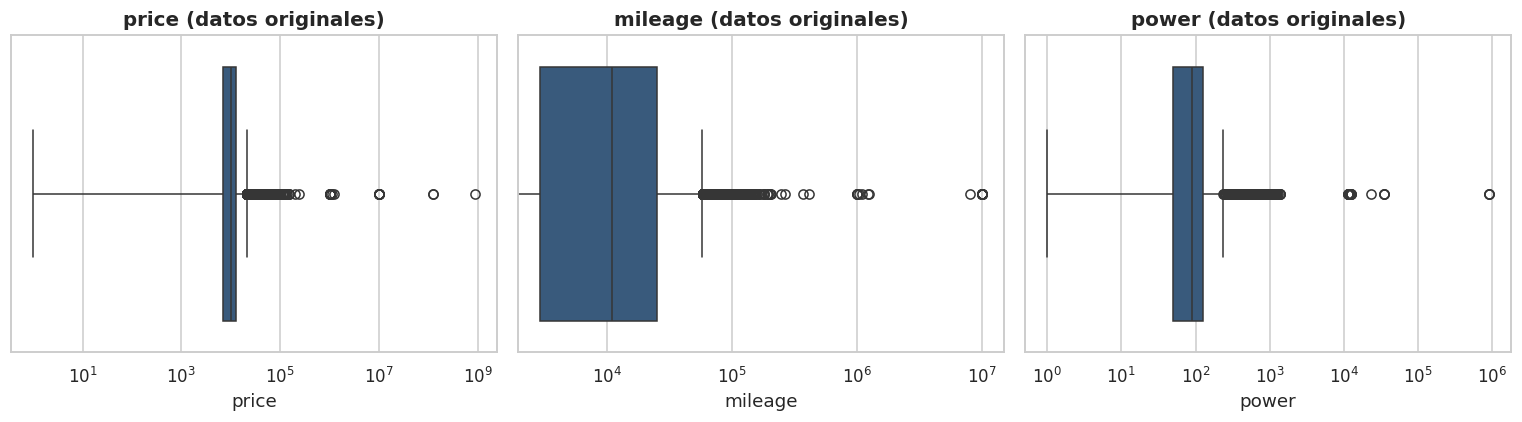

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["price", "mileage", "power"]):
    sns.boxplot(x=df_raw[col], ax=ax, color=COLOR)
    ax.set_title(f"{col} (datos originales)")
    ax.set_xscale("log")
plt.tight_layout()
plt.show()

Incluso en escala logarítmica, las tres variables muestran valores extremos separados del resto, lo que confirma los valores de relleno. Sin limpiar, cualquier media o gráfico saldría distorsionado.

### 2.9 Resumen de problemas detectados

| # | Problema | Columna(s) | Magnitud |
|---|---|---|---|
| 1 | Anuncios duplicados | todas | 5.833 filas |
| 2 | Fecha guardada como texto y valores no válidos | `date` | 28 sin fecha + 156 futuras |
| 3 | Precios de relleno o simbólicos | `price` | ~170 anuncios |
| 4 | Kilometrajes de relleno / imposibles | `mileage` | 25 anuncios |
| 5 | Motos usadas con 0 km | `mileage` + `offer_type` | 121 anuncios |
| 6 | Potencias imposibles (cilindradas, 1 CV) | `power` | ~750 anuncios |
| 7 | Marca y modelo mezclados | `make_model` | todo el dataset |
| 8 | Vehículos que no son motos | `make_model` | 5 anuncios |
| 9 | Categorías en inglés y con nulos | `fuel`, `gear`, `offer_type` | todo el dataset |
| 10 | Texto libre poco útil | `version` | 50% nulos |

*Cifras sobre los datos originales; algunas bajan un poco al quitar duplicados.*

## 3. Limpieza y normalización

Se trabaja sobre una copia para conservar los datos originales. Cada paso registra cuántas filas se eliminan.

**Criterio general:** solo se **eliminan filas** cuando el dato que falla es el precio (la variable principal) o cuando la fila no pertenece al dominio. Si falla una variable secundaria (km, potencia, fecha), se convierte ese valor en **nulo** y se conserva el resto del anuncio.

In [15]:
df = df_raw.copy()
registro = []

def registrar(paso, filas_antes):
    registro.append({"paso": paso, "filas_antes": filas_antes,
                     "filas_despues": len(df), "eliminadas": filas_antes - len(df)})

### 3.1 Duplicados
Se elimina cada anuncio repetido (mismo `link`) y se conserva la primera aparición.

In [16]:
n = len(df)
df = df.drop_duplicates(subset="link", keep="first")
registrar("Duplicados (mismo link)", n)
print(f"Eliminadas {n - len(df):,} filas duplicadas")

Eliminadas 5,833 filas duplicadas


### 3.2 Columnas que no se usan
- `link`: solo servía para detectar duplicados; no aporta información para el análisis.
- `version`: texto libre en varios idiomas, con 50% de nulos y valores sin significado ("0", "BTW MOTOR!"). Normalizarlo exigiría un trabajo de texto fuera del alcance del ejercicio.

In [17]:
df = df.drop(columns=["link", "version"])

### 3.3 Fechas: tipo y valores no válidos
- Se convierte `date` (texto `MM/YYYY`) a fecha real.
- `- (First Registration)` pasa a nulo: la moto aún no está matriculada.
- Las fechas posteriores al 16/07/2021 pasan a nulo: son imposibles en la fecha de captura.
- Se crean `anio_matriculacion` y `antiguedad_anios` (calculada respecto a la fecha de captura, no a hoy, para que la antigüedad refleje la del momento del anuncio).

In [18]:
fecha = pd.to_datetime(df["date"], format="%m/%Y", errors="coerce")
fecha = fecha.where(fecha <= FECHA_CAPTURA)          # futuras -> NaT

df["fecha_matriculacion"] = fecha
df["anio_matriculacion"] = fecha.dt.year.astype("Int64")
df["antiguedad_anios"] = ((FECHA_CAPTURA - fecha).dt.days / 365.25).round(1)
df = df.drop(columns="date")

print("Anuncios sin fecha de matriculación:", df["fecha_matriculacion"].isna().sum())

Anuncios sin fecha de matriculación: 160


### 3.4 Precio: valores de relleno y simbólicos
Como el precio es la variable principal, **se eliminan** los anuncios con:
- precios con patrón de relleno (123456, 999999, 1111111...);
- precios **menores de 300 €** (percentil 0,5): valores de 1, 2, 50 o 100 € que no son precios reales;
- precios **mayores de 250.000 €**. La moto legítima más cara es una Honda RC213V-S nueva (≈240.000 €), y por encima solo hay valores de relleno.

In [19]:
precio_relleno = df["price"].astype(str).str.fullmatch(r"(\d)\1{5,}|12345\d*")
precio_fuera = (df["price"] < 300) | (df["price"] > 250_000)

n = len(df)
df = df[~(precio_relleno | precio_fuera)]
registrar("Precios de relleno o fuera de rango", n)
print(f"Eliminados {n - len(df)} anuncios por precio no válido")

Eliminados 166 anuncios por precio no válido


### 3.5 Kilómetros
Pasan a nulo, sin eliminar la fila:
- valores de relleno (≥ 999.999 km) o superiores a 300.000 km, imposibles para una moto;
- motos **usadas con 0 km**, porque el dato es incoherente y probablemente no se rellenó.

In [20]:
km_invalido = df["mileage"] > 300_000
usada_0km = (df["offer_type"] == "Used") & (df["mileage"] == 0)

df["mileage"] = df["mileage"].astype(float).mask(km_invalido | usada_0km)
print("Km imposibles -> nulo:     ", km_invalido.sum())
print("Usadas con 0 km -> nulo:   ", usada_0km.sum())

Km imposibles -> nulo:      15
Usadas con 0 km -> nulo:    116


### 3.6 Potencia
Pasan a nulo las potencias **menores de 2 CV** (relleno, ni un ciclomotor de 50 cc baja de ~3 CV) y **mayores de 240 CV** (por encima de las motos de serie más potentes; son cilindradas o errores).

**Los nulos de potencia no se imputan.** Rellenarlos con la media o la mediana general asignaría 86 CV igual a un scooter que a una superbike y distorsionaría la distribución. Se dejan como nulos y se tienen en cuenta al interpretar.

In [21]:
potencia_invalida = (df["power"] < 2) | (df["power"] > 240)
df["power"] = df["power"].mask(potencia_invalida)
print("Potencias imposibles -> nulo:", potencia_invalida.sum())

Potencias imposibles -> nulo: 648


### 3.7 Marca y modelo
Se separa `make_model` en `marca` y `modelo`, teniendo en cuenta las marcas de dos palabras. Si solo aparece la marca, el modelo queda nulo. `Others` pasa a `Otras`.

In [22]:
MARCAS_COMPUESTAS = ["Moto Guzzi", "Moto Morini", "MV Agusta", "Can Am", "CF Moto",
                     "Royal Enfield", "Arctic Cat", "Brough Superior", "Big Dog",
                     "Super Soco", "Nova Motors", "Boom Trike", "KSR Moto"]

def separar_marca_modelo(texto):
    """Devuelve (marca, modelo). El modelo es NaN si solo viene la marca."""
    for marca in MARCAS_COMPUESTAS:
        if texto == marca or texto.startswith(marca + " "):
            modelo = texto[len(marca):].strip()
            return marca, modelo if modelo else np.nan
    partes = texto.split(" ", 1)
    return partes[0], partes[1] if len(partes) > 1 else np.nan

separado = df["make_model"].apply(separar_marca_modelo)
df["marca"] = separado.str[0].replace({"Others": "Otras"})
df["modelo"] = separado.str[1]
df = df.drop(columns="make_model")

df[["marca", "modelo"]].sample(5, random_state=7)

,marca,modelo
25169,Kawasaki,Z 900
3356,Triumph,Bonneville Bobber
15551,Yamaha,Slider 50
16878,BMW,R 1250 R
29192,Leonart,Spyder


### 3.8 Vehículos que no son motos
Se eliminan los anuncios de Opel, Fiat y Jeep: son coches o furgonetas que no pertenecen al dominio del dataset.

In [23]:
n = len(df)
df = df[~df["marca"].isin(["Opel", "Fiat", "Jeep"])]
registrar("Vehículos que no son motos", n)
print(f"Eliminados {n - len(df)} anuncios")

Eliminados 5 anuncios


### 3.9 Normalización de categorías
Se traducen las categorías al español para que el análisis sea más legible. Los nulos de combustible y cambio se sustituyen por `Desconocido` en lugar de imputarlos, porque no hay forma fiable de deducirlos y así quedan visibles en los gráficos.

In [24]:
df["combustible"] = df["fuel"].map({
    "Gasoline": "Gasolina", "Two Stroke Gasoline": "Gasolina 2T", "Electric": "Eléctrica",
    "Electric/Gasoline": "Híbrida", "Diesel": "Diésel", "LPG": "GLP", "Others": "Otros"
}).fillna("Desconocido")

df["cambio"] = df["gear"].map({
    "Manual": "Manual", "Automatic": "Automático", "Semi-automatic": "Semiautomático"
}).fillna("Desconocido")

df["tipo_oferta"] = df["offer_type"].map({
    "Used": "Usada", "New": "Nueva", "Demonstration": "Demostración",
    "Pre-registered": "Km 0", "Antique / Classic": "Clásica"
})

df = df.drop(columns=["fuel", "gear", "offer_type"])

### 3.10 Nombres de columnas, orden final y guardado

In [25]:
df = df.rename(columns={"price": "precio_eur", "mileage": "km", "power": "potencia_cv"})
df = df[["marca", "modelo", "precio_eur", "km", "potencia_cv", "fecha_matriculacion",
         "anio_matriculacion", "antiguedad_anios", "combustible", "cambio", "tipo_oferta"]]
df = df.reset_index(drop=True)

df.to_csv(RUTA_LIMPIO, index=False)
print(f"Dataset limpio guardado en {RUTA_LIMPIO}")
df.info()

Dataset limpio guardado en ../data/dataset_clean.csv
<class 'pandas.DataFrame'>
RangeIndex: 28913 entries, 0 to 28912
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   marca                28913 non-null  object        
 1   modelo               25982 non-null  object        
 2   precio_eur           28913 non-null  int64         
 3   km                   28782 non-null  float64       
 4   potencia_cv          22864 non-null  float64       
 5   fecha_matriculacion  28753 non-null  datetime64[us]
 6   anio_matriculacion   28753 non-null  Int64         
 7   antiguedad_anios     28753 non-null  float64       
 8   combustible          28913 non-null  str           
 9   cambio               28913 non-null  str           
 10  tipo_oferta          28913 non-null  str           
dtypes: Int64(1), datetime64[us](1), float64(3), int64(1), object(2), str(3)
memory usage: 2.5+ MB


### 3.11 Resultado de la limpieza

In [26]:
pd.DataFrame(registro)

,paso,filas_antes,filas_despues,eliminadas
0,Duplicados (mismo link),34917,29084,5833
1,Precios de relleno o fuera de rango,29084,28918,166
2,Vehículos que no son motos,28918,28913,5


In [27]:
print(f"Filas originales: {len(df_raw):,}  ->  filas finales: {len(df):,} "
      f"({len(df) / len(df_raw):.1%} conservado)\n")

pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(1)
})

Filas originales: 34,917  ->  filas finales: 28,913 (82.8% conservado)



,nulos,porcentaje
marca,0,0.00
modelo,2931,10.10
precio_eur,0,0.00
km,131,0.50
potencia_cv,6049,20.90
fecha_matriculacion,160,0.60
anio_matriculacion,160,0.60
antiguedad_anios,160,0.60
combustible,0,0.00
cambio,0,0.00


In [28]:
df[["precio_eur", "km", "potencia_cv", "antiguedad_anios"]].describe().T

,count,mean,std,min,25%,50%,75%,max
precio_eur,"28,913.00","10,404.71","7,912.80",300.00,"6,500.00","9,000.00","13,398.00","239,993.00"
km,"28,782.00","17,011.71","19,540.80",0.00,"2,700.00","10,695.00","24,500.00","265,000.00"
potencia_cv,"22,864.00",86.51,52.44,3.00,48.00,86.00,125.00,239.00
antiguedad_anios,"28,753.00",7.76,10.28,0.00,2.20,5.20,9.40,114.10


Después de limpiar, los rangos son realistas: precios de 300 a ~240.000 €, un máximo de 265.000 km y potencias de 3 a 239 CV. La media del precio (~10.400 €) ya está cerca de la mediana (9.000 €).

Quedan nulos **conocidos y justificados**: potencia (~21%), modelo (~10%, anuncios con solo la marca) y fecha (~0,6%, motos sin matricular). Los de combustible y cambio están marcados como `Desconocido`.

## 4. Visualizaciones básicas

### 4.1 ¿Cómo se distribuye el precio? (histograma)

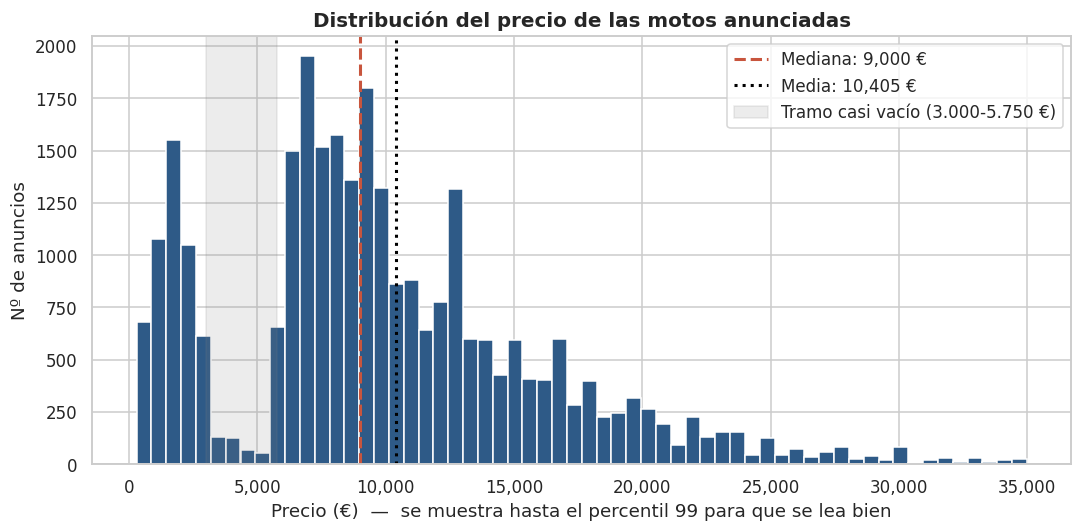

El 50% de las motos cuesta entre 6,500 € y 13,398 €



,anuncios
precio_eur,
"(1500, 2000]",1270
"(2000, 2500]",907
"(2500, 3000]",741
"(3000, 3500]",112
"(3500, 4000]",141
"(4000, 4500]",45
"(4500, 5000]",69
"(5000, 5500]",28
"(5500, 6000]",648


In [29]:
p99 = df["precio_eur"].quantile(0.99)
media, mediana = df["precio_eur"].mean(), df["precio_eur"].median()

fig, ax = plt.subplots()
ax.hist(df.loc[df["precio_eur"] <= p99, "precio_eur"], bins=60, color=COLOR, edgecolor="white")
ax.axvline(mediana, color=COLOR_2, ls="--", lw=2, label=f"Mediana: {mediana:,.0f} €")
ax.axvline(media, color="black", ls=":", lw=2, label=f"Media: {media:,.0f} €")
ax.set_title("Distribución del precio de las motos anunciadas")
ax.set_xlabel("Precio (€)  —  se muestra hasta el percentil 99 para que se lea bien")
ax.set_ylabel("Nº de anuncios")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.axvspan(3000, 5750, color="grey", alpha=0.15, label="Tramo casi vacío (3.000-5.750 €)")
ax.legend()
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / "01_histograma_precio.png", bbox_inches="tight")
plt.show()

print(f"El 50% de las motos cuesta entre {df['precio_eur'].quantile(.25):,.0f} € "
      f"y {df['precio_eur'].quantile(.75):,.0f} €\n")

# Comprobación del tramo casi vacío: anuncios por franjas de 500 €
tramos = pd.cut(df["precio_eur"], bins=range(1500, 7501, 500))
tramos.value_counts().sort_index().to_frame("anuncios")

El histograma revela tres cosas:
- **Asimetría a la derecha:** una cola larga de motos caras (superbikes, ediciones limitadas, clásicas) empuja la media por encima de la mediana. Por eso, en el resto del análisis se usa la **mediana**.
- **Dos grupos:** un bloque de motos baratas (500-3.000 €, sobre todo scooters y ciclomotores) y el bloque principal (6.000-13.000 €).
- **Un hueco sospechoso entre 3.000 y 5.750 €:** cada franja de 500 € de ese tramo tiene entre 28 y 141 anuncios, frente a 650-1.800 en las franjas vecinas (unos 400 en total en un rango de casi 3.000 €). Un mercado real no tiene ese vacío, justo en la gama de las motos pequeñas usadas. Lo más probable es que sea **un defecto de la recogida de datos** (el scraping se hizo por rangos de precio y ese rango se perdió en gran parte). **Consecuencia:** el dataset no representa bien las motos de ese precio y la mediana general está algo inflada. No se puede corregir limpiando; se documenta como limitación.

También se ven picos en precios redondos (9.000 €, 13.000 €), típicos de los anuncios.

### 4.2 ¿Qué marcas son las más frecuentes? (gráfico de barras)

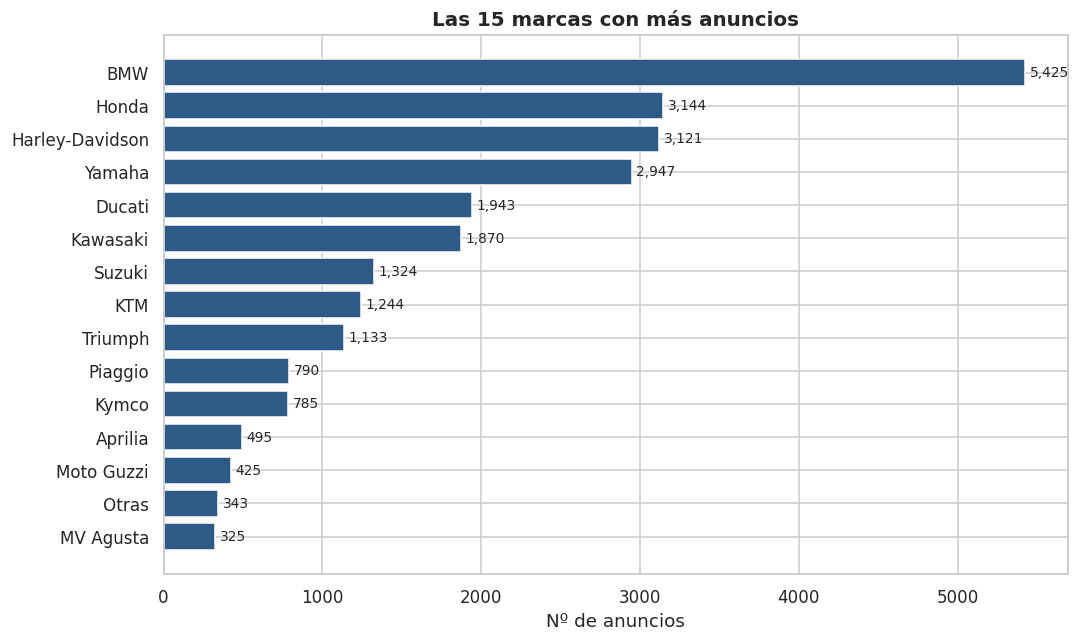

Cuota de las 5 primeras marcas: 57.3%


In [30]:
top_marcas = df["marca"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.barh(top_marcas.index, top_marcas.values, color=COLOR)
ax.bar_label(barras, labels=[f"{v:,}" for v in top_marcas.values], padding=3, fontsize=9)
ax.set_title("Las 15 marcas con más anuncios")
ax.set_xlabel("Nº de anuncios")
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / "02_barras_marcas.png", bbox_inches="tight")
plt.show()

cuota = df["marca"].value_counts(normalize=True).head(5)
print("Cuota de las 5 primeras marcas:", f"{cuota.sum():.1%}")

**BMW** domina claramente (≈19% de los anuncios), seguida de Honda, Harley-Davidson y Yamaha. Las cinco primeras marcas acumulan más de la mitad del mercado analizado. Tiene sentido, porque la fuente es un marketplace con fuerte peso en Alemania y el centro de Europa.

### 4.3 ¿Hay diferencias de precio entre marcas? (diagrama de cajas)

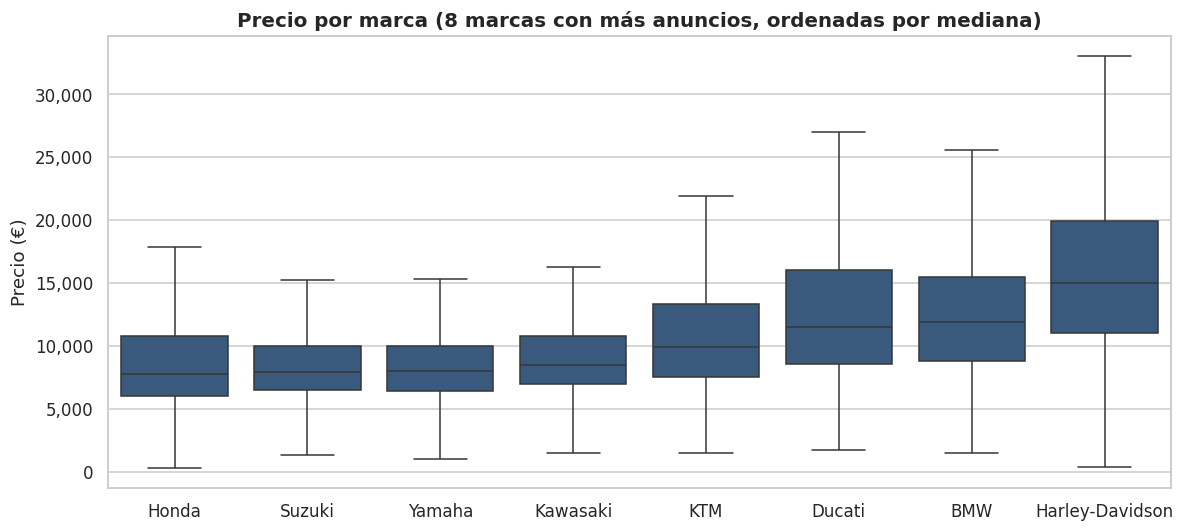

,mediana_eur
marca,
Harley-Davidson,"15,000.00"
BMW,"11,900.00"
Ducati,"11,490.00"
KTM,"9,890.00"
Kawasaki,"8,500.00"
Yamaha,"8,000.00"
Suzuki,"7,950.00"
Honda,"7,790.00"


In [31]:
marcas_top8 = df["marca"].value_counts().head(8).index
datos = df[df["marca"].isin(marcas_top8)]
orden = datos.groupby("marca")["precio_eur"].median().sort_values().index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=datos, x="marca", y="precio_eur", order=orden, color=COLOR,
            showfliers=False, ax=ax)
ax.set_title("Precio por marca (8 marcas con más anuncios, ordenadas por mediana)")
ax.set_xlabel("")
ax.set_ylabel("Precio (€)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / "03_boxplot_precio_marca.png", bbox_inches="tight")
plt.show()

datos.groupby("marca")["precio_eur"].median().sort_values(ascending=False).to_frame("mediana_eur")

Hay dos grupos claros:
- **Marcas japonesas** (Honda, Suzuki, Yamaha, Kawasaki): medianas de 7.800 a 8.500 €, con una oferta que incluye muchos scooters y motos de gama media.
- **Marcas europeas y americanas** (KTM, Ducati, BMW, Harley-Davidson): medianas más altas. **Harley-Davidson** es la más cara (15.000 € de mediana), casi el doble que Honda.

*Los valores atípicos se ocultan en el gráfico (`showfliers=False`) para que las cajas se lean bien; siguen en los datos.*

### 4.4 ¿Cómo varía el precio con la antigüedad de la moto?

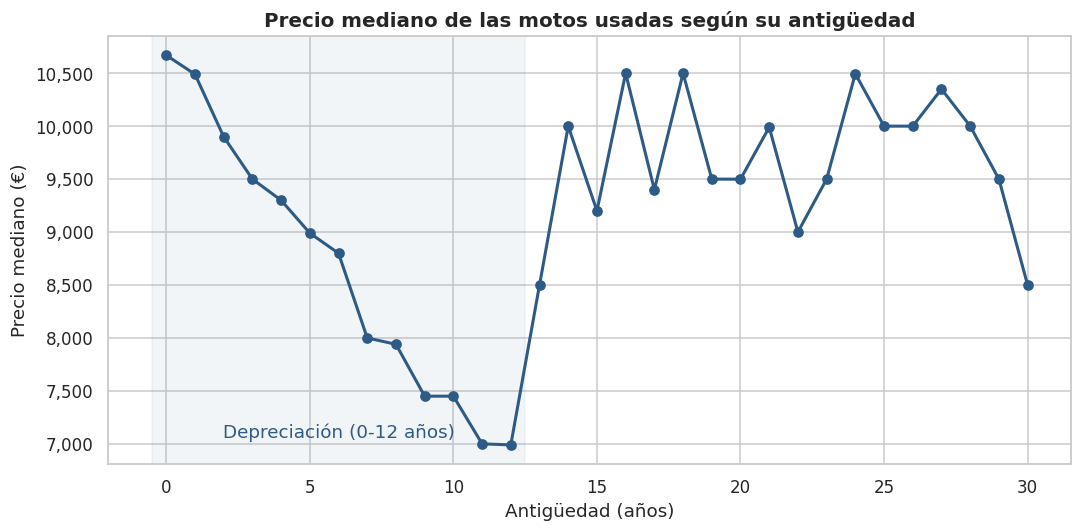

,median,count
antiguedad_redondeada,,
0,"10,669.50",1230
5,"8,990.00",1749
10,"7,450.00",1480
12,"6,990.00",1283
15,"9,200.00",199
20,"9,499.00",147
25,"10,000.00",48


In [32]:
usadas = df[(df["tipo_oferta"] == "Usada") & df["antiguedad_anios"].between(0, 30)].copy()
usadas["antiguedad_redondeada"] = usadas["antiguedad_anios"].round().astype(int)
por_edad = usadas.groupby("antiguedad_redondeada")["precio_eur"].agg(["median", "count"])

fig, ax = plt.subplots()
ax.plot(por_edad.index, por_edad["median"], marker="o", color=COLOR, lw=2)
ax.set_title("Precio mediano de las motos usadas según su antigüedad")
ax.set_xlabel("Antigüedad (años)")
ax.set_ylabel("Precio mediano (€)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.axvspan(-0.5, 12.5, color=COLOR, alpha=0.06)
ax.text(6, por_edad["median"].min() * 1.01, "Depreciación (0-12 años)", ha="center", color=COLOR)
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / "04_precio_antiguedad.png", bbox_inches="tight")
plt.show()

por_edad.loc[[0, 5, 10, 12, 15, 20, 25]]

Aparece un patrón interesante en dos fases:
- **De 0 a 12 años el precio baja de forma constante:** de ~10.700 € a ~7.000 €, es decir, una moto usada pierde en torno a un tercio de su precio en ese periodo.
- **A partir de ~13 años el precio deja de bajar e incluso sube** (8.500-10.500 €). No es que las motos se revaloricen en general. Hay dos explicaciones que se suman:
  - un **sesgo de selección**: de las motos viejas se anuncian sobre todo las que conservan valor (clásicas, customs, modelos de culto);
  - el **hueco de precios** visto en 4.1: una moto de 13-20 años caería con frecuencia justo en el tramo de 3.000-5.750 €, que casi falta en el dataset. Al faltar esas motos, la mediana de las antiguas sale artificialmente alta.

  Por tanto, **este repunte no debe interpretarse como un comportamiento real del mercado** sin datos más completos.

Además, hay pocos anuncios por año a partir de los 20 años, así que esa parte de la curva es menos fiable.

### 4.5 ¿Qué relación hay entre potencia y precio?

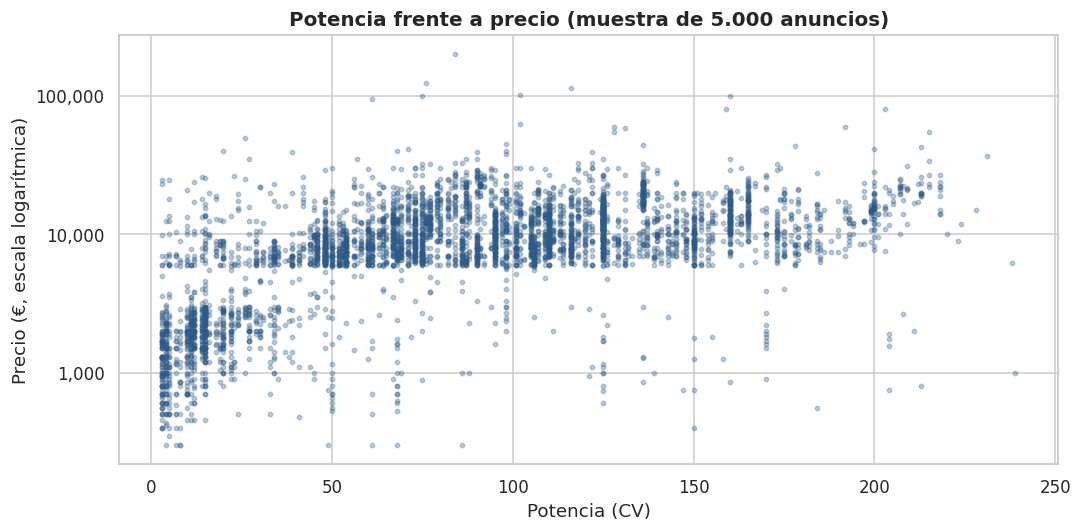

,precio_eur,km,potencia_cv,antiguedad_anios
precio_eur,1.00,-0.10,0.58,-0.18
km,-0.10,1.00,0.17,0.63
potencia_cv,0.58,0.17,1.00,-0.06
antiguedad_anios,-0.18,0.63,-0.06,1.00


In [33]:
con_potencia = df.dropna(subset=["potencia_cv"])
muestra = con_potencia.sample(5000, random_state=42)   # muestra para que el gráfico no se sature

fig, ax = plt.subplots()
ax.scatter(muestra["potencia_cv"], muestra["precio_eur"], s=8, alpha=0.3, color=COLOR)
ax.set_yscale("log")
ax.set_title("Potencia frente a precio (muestra de 5.000 anuncios)")
ax.set_xlabel("Potencia (CV)")
ax.set_ylabel("Precio (€, escala logarítmica)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / "05_potencia_precio.png", bbox_inches="tight")
plt.show()

corr = df[["precio_eur", "km", "potencia_cv", "antiguedad_anios"]].corr(method="spearman")
corr.round(2)

La **potencia es la variable numérica más relacionada con el precio** (correlación de Spearman ≈ 0,58): más potencia suele implicar una moto más cara, aunque con mucha dispersión (a igual potencia, una Harley y una japonesa tienen precios muy distintos).

Los kilómetros apenas se relacionan con el precio (≈ −0,10), pero sí con la antigüedad (≈ 0,63), algo lógico. Se usa Spearman en lugar de Pearson porque las variables son asimétricas y tienen valores extremos.

## 5. Conclusiones exploratorias

### Características del dataset
- **28.913 anuncios** de motos (tras la limpieza) de un marketplace europeo, recogidos en julio de 2021. Una fila = un anuncio.
- 11 variables finales: marca, modelo, precio, km, potencia, fecha/año/antigüedad de matriculación, combustible, cambio y tipo de oferta.
- Predominan las **motos usadas (90%)** y de **gasolina (87%)**. Las eléctricas son marginales (~1,3%).
- El mercado está muy concentrado: **BMW** tiene ≈19% de los anuncios y las 5 primeras marcas superan la mitad.

### Principales hallazgos
1. **Precio:** mediana de 9.000 €, con el 50% central entre 6.500 y 13.400 €. La distribución es asimétrica a la derecha y tiene dos grupos (scooters baratos y motos de gama media).
2. **Marca:** las japonesas son las más asequibles (≈8.000 €) y **Harley-Davidson** la más cara (15.000 €), casi el doble.
3. **Antigüedad:** las motos usadas se deprecian de forma sostenida durante unos 12 años (pierden ~1/3 del precio). El repunte posterior se explica por un sesgo de selección (clásicas, customs) y por el hueco de precios del dataset, así que no es fiable.
4. **Potencia:** es la variable más relacionada con el precio (ρ ≈ 0,58). Los km apenas influyen una vez tenida en cuenta la antigüedad.
5. **Dataset incompleto:** casi no hay anuncios entre 3.000 y 5.750 €, algo que no ocurre en un mercado real. Es muy probablemente un fallo de la recogida de datos, no una característica del mercado.
6. **Calidad del dato:** al ser anuncios introducidos a mano, abundan los valores de relleno (precios 999999, 1 CV, cilindradas en la columna de potencia). Cualquier análisis sobre este mercado necesita esta limpieza previa.

### Cambios aplicados durante la limpieza

| Paso | Acción | Efecto |
|---|---|---|
| Duplicados | Eliminados anuncios con el mismo `link` | −5.833 filas |
| Precio | Eliminados precios de relleno, < 300 € o > 250.000 € | −166 filas |
| Dominio | Eliminados coches/furgonetas (Opel, Fiat, Jeep) | −5 filas |
| Fechas | Texto → fecha; sin matricular y futuras → nulo; creadas año y antigüedad | 160 nulos |
| Km | Relleno y > 300.000 km → nulo; usadas con 0 km → nulo | 131 nulos |
| Potencia | < 2 CV o > 240 CV → nulo (sin imputar) | 648 valores anulados |
| Marca/modelo | `make_model` separado en dos columnas (marcas compuestas incluidas) | 2 columnas nuevas |
| Categorías | Traducidas al español; nulos → `Desconocido` | 3 columnas normalizadas |
| Columnas | Eliminadas `link` y `version`; renombradas en español | 11 columnas finales |

En total se conserva el **82,8% de las filas originales**. Casi toda la reducción se debe a duplicados, no a pérdida de información.

### Limitaciones
- **Falta casi todo el tramo de 3.000-5.750 €** (probable fallo del scraping). Las conclusiones sobre precios medios deben tomarse con cautela, sobre todo para motos pequeñas usadas.
- El precio es el **precio pedido**, no el de venta.
- Pueden quedar errores no detectables con reglas generales (por ejemplo, un Suzuki Burgman 400 anunciado a 150.000 €). Detectarlos exigiría comparar cada precio con el de su modelo.
- `cambio` tiene un 63% de valores desconocidos, así que no se ha usado en el análisis.